In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("../data/raw_data.csv")

df.head()

,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,0,0,0,0,0
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,0,0,0,0,0
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,0,0,0,0,0
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,0,0,0,0,0
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,0,0,0,0,0


In [2]:
df.shape
df.info()
df.describe()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   UDI                      10000 non-null  int64  
 1   Product ID               10000 non-null  str    
 2   Type                     10000 non-null  str    
 3   Air temperature [K]      10000 non-null  float64
 4   Process temperature [K]  10000 non-null  float64
 5   Rotational speed [rpm]   10000 non-null  int64  
 6   Torque [Nm]              10000 non-null  float64
 7   Tool wear [min]          10000 non-null  int64  
 8   Machine failure          10000 non-null  int64  
 9   TWF                      10000 non-null  int64  
 10  HDF                      10000 non-null  int64  
 11  PWF                      10000 non-null  int64  
 12  OSF                      10000 non-null  int64  
 13  RNF                      10000 non-null  int64  
dtypes: float64(3), int64(9), str(2)
me

,UDI,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
count,10000.00000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000
mean,5000.50000,300.004930,310.005560,1538.776100,39.986910,107.951000,0.033900,0.004600,0.011500,0.009500,0.009800,0.00190
std,2886.89568,2.000259,1.483734,179.284096,9.968934,63.654147,0.180981,0.067671,0.106625,0.097009,0.098514,0.04355
min,1.00000,295.300000,305.700000,1168.000000,3.800000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
25%,2500.75000,298.300000,308.800000,1423.000000,33.200000,53.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
50%,5000.50000,300.100000,310.100000,1503.000000,40.100000,108.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
75%,7500.25000,301.500000,311.100000,1612.000000,46.800000,162.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
max,10000.00000,304.500000,313.800000,2886.000000,76.600000,253.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.00000


In [3]:
df.isnull().sum()

UDI                        0
Product ID                 0
Type                       0
Air temperature [K]        0
Process temperature [K]    0
Rotational speed [rpm]     0
Torque [Nm]                0
Tool wear [min]            0
Machine failure            0
TWF                        0
HDF                        0
PWF                        0
OSF                        0
RNF                        0
dtype: int64

In [5]:
df.drop(['UDI', 'Product ID'], axis=1, inplace=True)

KeyError: "['UDI', 'Product ID'] not found in axis"

In [6]:
print(df.columns)

Index(['Type', 'Air temperature [K]', 'Process temperature [K]',
       'Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]',
       'Machine failure', 'TWF', 'HDF', 'PWF', 'OSF', 'RNF'],
      dtype='str')


In [7]:
df = pd.get_dummies(df, columns=['Type'], drop_first=True)

In [8]:
print(df.columns)
df.head()

Index(['Air temperature [K]', 'Process temperature [K]',
       'Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]',
       'Machine failure', 'TWF', 'HDF', 'PWF', 'OSF', 'RNF', 'Type_L',
       'Type_M'],
      dtype='str')


,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF,Type_L,Type_M
0,298.1,308.6,1551,42.8,0,0,0,0,0,0,0,False,True
1,298.2,308.7,1408,46.3,3,0,0,0,0,0,0,True,False
2,298.1,308.5,1498,49.4,5,0,0,0,0,0,0,True,False
3,298.2,308.6,1433,39.5,7,0,0,0,0,0,0,True,False
4,298.2,308.7,1408,40.0,9,0,0,0,0,0,0,True,False


In [9]:
df.to_csv("../data/cleaned_data.csv", index=False)

In [10]:
failure_rate = df['Machine failure'].mean() * 100
print("Machine Failure Rate:", failure_rate)

Machine Failure Rate: 3.39


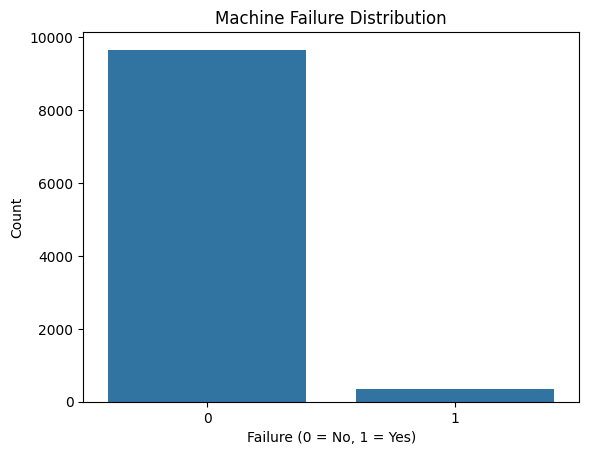

In [11]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x='Machine failure', data=df)
plt.title("Machine Failure Distribution")
plt.xlabel("Failure (0 = No, 1 = Yes)")
plt.ylabel("Count")
plt.show()

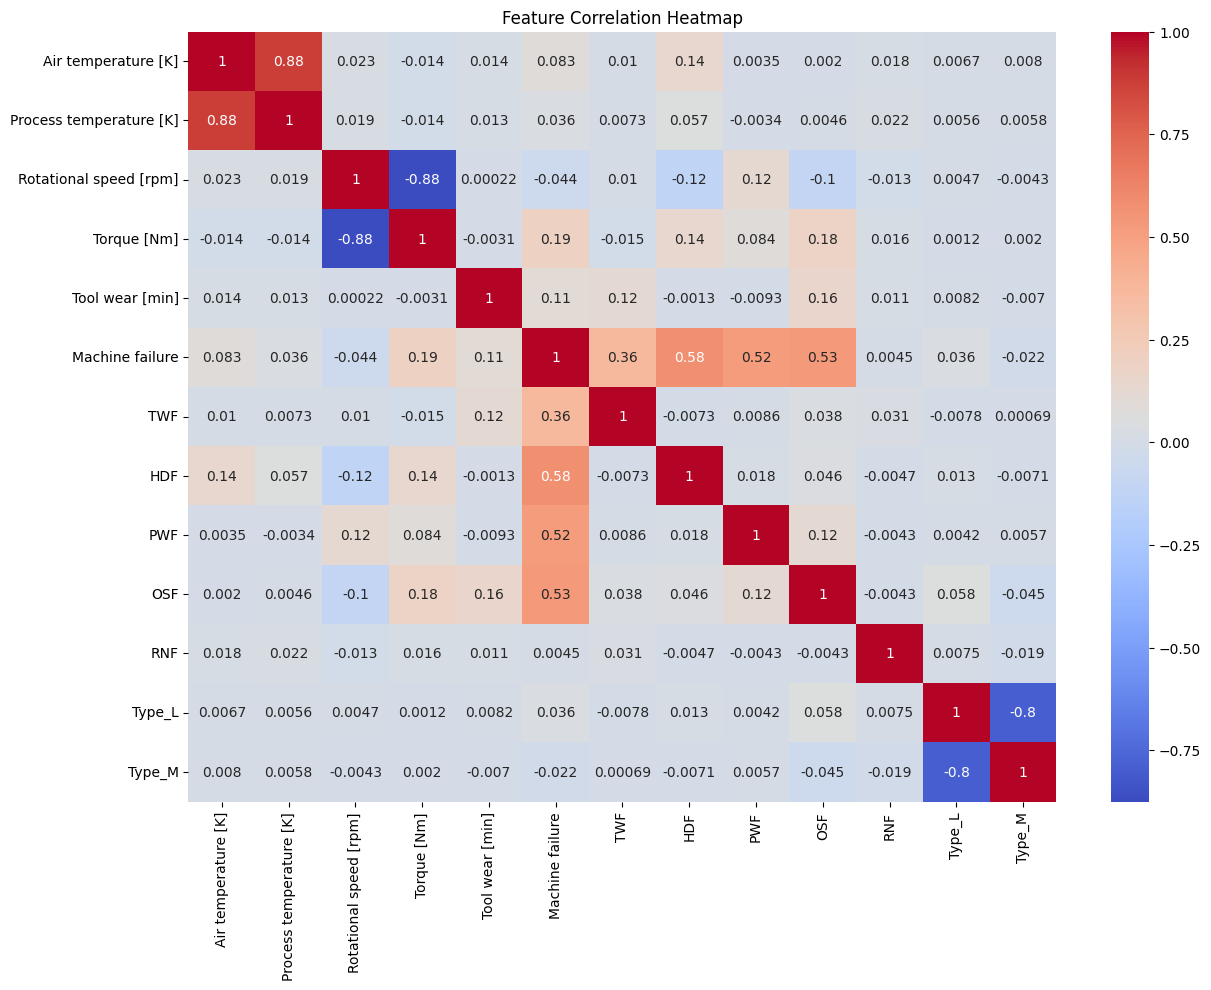

In [12]:
plt.figure(figsize=(14,10))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.title("Feature Correlation Heatmap")
plt.show()

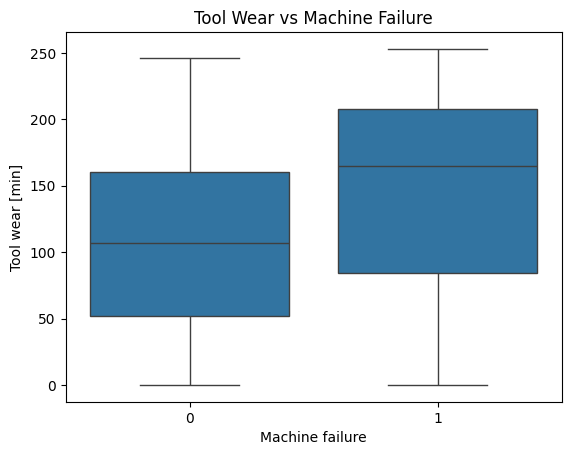

In [13]:
sns.boxplot(x='Machine failure', y='Tool wear [min]', data=df)
plt.title("Tool Wear vs Machine Failure")
plt.show()

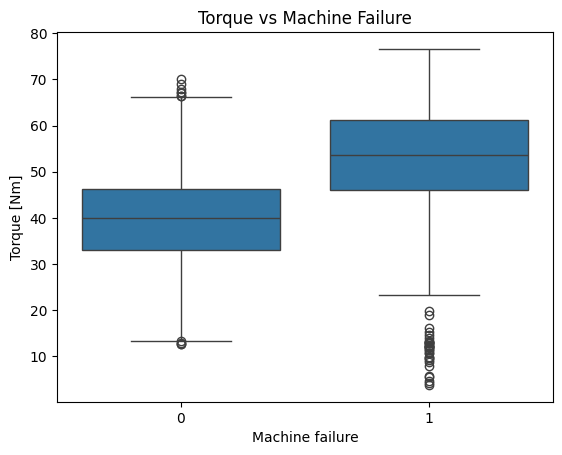

In [14]:
sns.boxplot(x='Machine failure', y='Torque [Nm]', data=df)
plt.title("Torque vs Machine Failure")
plt.show()

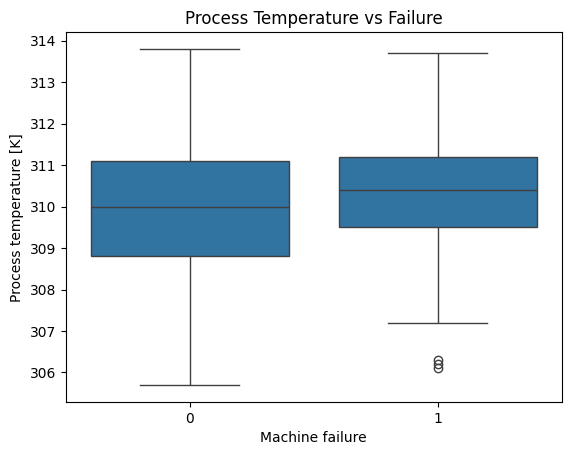

In [15]:
sns.boxplot(x='Machine failure', y='Process temperature [K]', data=df)
plt.title("Process Temperature vs Failure")
plt.show()

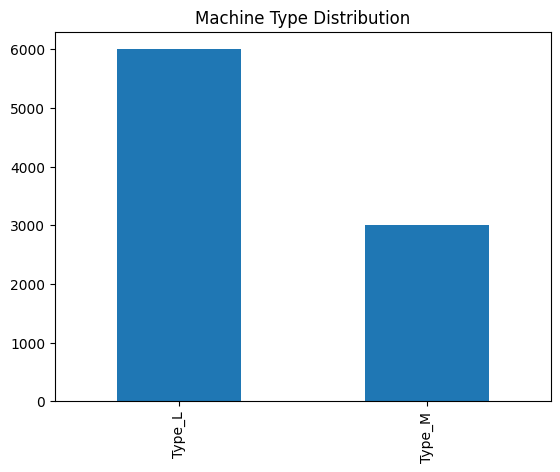

In [18]:
type_cols = ['Type_L', 'Type_M']
df[type_cols].sum().plot(kind='bar')
plt.title("Machine Type Distribution")
plt.show()

In [19]:
print("Failure Rate:", df['Machine failure'].mean()*100)
print("Average Torque:", df['Torque [Nm]'].mean())
print("Average Tool Wear:", df['Tool wear [min]'].mean())
print("Average Rotational Speed:", df['Rotational speed [rpm]'].mean())

Failure Rate: 3.39
Average Torque: 39.986909999999995
Average Tool Wear: 107.951
Average Rotational Speed: 1538.7761


In [20]:
kpi_report = {
    "Failure Rate": df['Machine failure'].mean()*100,
    "Average Torque": df['Torque [Nm]'].mean(),
    "Average Tool Wear": df['Tool wear [min]'].mean(),
    "Average RPM": df['Rotational speed [rpm]'].mean()
}

report_df = pd.DataFrame([kpi_report])
report_df.to_csv("../reports/kpi_summary.csv", index=False)

In [21]:
df.rename(columns={
    'Air temperature [K]': 'air_temp',
    'Process temperature [K]': 'process_temp',
    'Rotational speed [rpm]': 'rotational_speed',
    'Torque [Nm]': 'torque',
    'Tool wear [min]': 'tool_wear',
    'Machine failure': 'machine_failure',
    'TWF': 'twf',
    'HDF': 'hdf',
    'PWF': 'pwf',
    'OSF': 'osf',
    'RNF': 'rnf',
    'Type_L': 'type_l',
    'Type_M': 'type_m'
}, inplace=True)

In [22]:
df.to_csv("../data/cleaned_data_supabase.csv", index=False)

In [23]:
bool_columns = ['twf', 'hdf', 'pwf', 'osf', 'rnf', 'type_l', 'type_m']

for col in bool_columns:
    df[col] = df[col].astype(int)

In [24]:
df[bool_columns].head()

,twf,hdf,pwf,osf,rnf,type_l,type_m
0,0,0,0,0,0,0,1
1,0,0,0,0,0,1,0
2,0,0,0,0,0,1,0
3,0,0,0,0,0,1,0
4,0,0,0,0,0,1,0


In [25]:
df.to_csv("../data/cleaned_data_supabase_final.csv", index=False)